# Tabular Machine Learning Regression Pipeline
## End-to-End Workflow Demo

This notebook walks through the full ML pipeline:

1. Load and explore the dataset
2. Train a Gradient Boosting Regressor
3. Generate predictions on the evaluation set
4. Save and visualise outputs

**Dataset:** 273 numerical features · 10,000 training samples · 10,000 evaluation samples  
**Task:** Predict two continuous targets (`target01`, `target02`)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure paths resolve correctly whether notebook is run from root or notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())
print("Project root:", ROOT)

Project root: /Users/ahmedali/Desktop/machine learning project


---
## 1. Project Overview

This project builds a regression pipeline over a high-dimensional tabular dataset.

| Target | Approach | Key Metric |
|---|---|---|
| `target01` | Gradient Boosting Regressor | R² = 0.688 |
| `target02` | Rule-based threshold model | R² = 0.360 |

This notebook focuses on **target01** — the supervised learning task.

---
## 2. Load Dataset

In [2]:
train_features = pd.read_csv(os.path.join(ROOT, "data", "train_features.csv"))
train_targets  = pd.read_csv(os.path.join(ROOT, "data", "train_targets.csv"))
eval_features  = pd.read_csv(os.path.join(ROOT, "data", "eval_features.csv"))

print(f"train_features : {train_features.shape}")
print(f"train_targets  : {train_targets.shape}")
print(f"eval_features  : {eval_features.shape}")

train_features : (10000, 273)
train_targets  : (10000, 2)
eval_features  : (10000, 273)


---
## 3. Data Exploration

In [3]:
# Sample rows
print("Feature matrix (first 3 rows, first 8 columns):")
train_features.iloc[:3, :8]

Feature matrix (first 3 rows, first 8 columns):


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7
0,-0.241630,0.141499,-0.049194,0.973430,0.786981,0.396660,3.108137,1.437338
1,-3.405931,0.662019,0.389838,0.798403,0.333903,0.488537,0.680859,-1.439824
2,-2.831021,0.776005,0.605729,0.936057,0.218925,0.546701,6.012680,-1.160440


In [4]:
# Target statistics
print("Target variable statistics:")
train_targets.describe().round(4)

Target variable statistics:


,target01,target02
count,10000.0000,10000.0000
mean,0.5091,0.2879
std,0.2258,0.8651
min,0.0960,-1.8071
25%,0.3353,-0.3491
50%,0.4069,0.1991
75%,0.7014,0.7499
max,1.1485,2.8777


In [5]:
# Missing value check
print("Missing values — features:", train_features.isnull().sum().sum())
print("Missing values — targets: ", train_targets.isnull().sum().sum())
print("Missing values — eval:    ", eval_features.isnull().sum().sum())

Missing values — features: 0
Missing values — targets:  0
Missing values — eval:     0


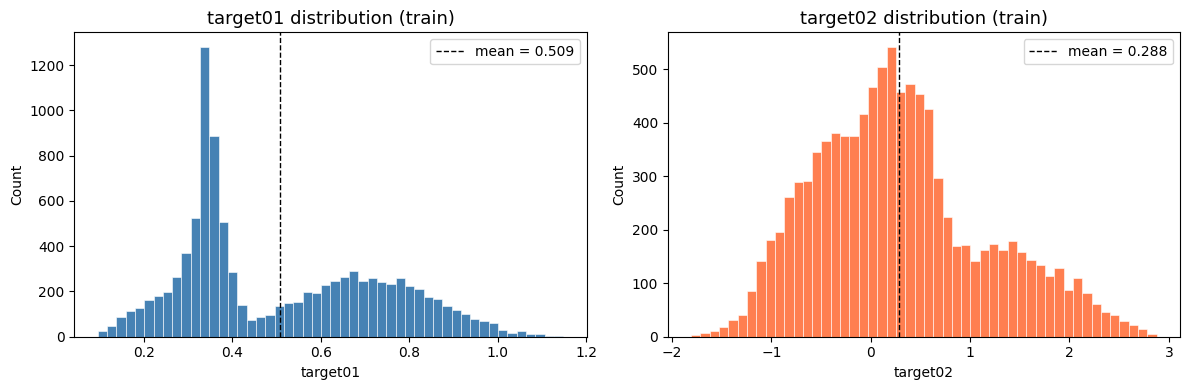

In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes, ["target01", "target02"], ["steelblue", "coral"]):
    ax.hist(train_targets[col], bins=50, color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(f"{col} distribution (train)", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.axvline(train_targets[col].mean(), color="black", linestyle="--", linewidth=1, label=f"mean = {train_targets[col].mean():.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Model Training

A **Gradient Boosting Regressor** is trained on `target01`. Hyperparameters were selected by grid search:

| Parameter | Value |
|---|---|
| `n_estimators` | 200 |
| `max_depth` | 4 |
| `learning_rate` | 0.05 |
| `random_state` | 42 |

In [7]:
X_train = train_features.values
y_train = train_targets["target01"].values
X_eval  = eval_features.values

model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
)

print("Training model...")
model.fit(X_train, y_train)
print("Training complete.")

Training model...


Training complete.


In [8]:
# Training-set performance (in-sample)
train_preds = model.predict(X_train)
print("In-sample performance:")
print(f"  RMSE : {mean_squared_error(y_train, train_preds) ** 0.5:.4f}")
print(f"  MAE  : {mean_absolute_error(y_train, train_preds):.4f}")
print(f"  R²   : {r2_score(y_train, train_preds):.4f}")

In-sample performance:
  RMSE : 0.1545
  MAE  : 0.1373
  R²   : 0.5320


---
## 5. Generate Predictions on Evaluation Set

In [9]:
eval_preds = model.predict(X_eval)

print(f"Predictions generated: {len(eval_preds):,} rows")
print(f"  Min  : {eval_preds.min():.4f}")
print(f"  Max  : {eval_preds.max():.4f}")
print(f"  Mean : {eval_preds.mean():.4f}")
print(f"  Std  : {eval_preds.std():.4f}")

Predictions generated: 10,000 rows
  Min  : 0.1956
  Max  : 0.7670
  Mean : 0.5089
  Std  : 0.0810


---
## 6. Save Predictions

In [10]:
output_path = os.path.join(ROOT, "predictions", "target01_predictions.csv")
os.makedirs(os.path.dirname(output_path), exist_ok=True)

pd.DataFrame({"target01": eval_preds}).to_csv(output_path, index=False)
print(f"Predictions saved to: {output_path}")

# Verify
saved = pd.read_csv(output_path)
print(f"Saved file shape: {saved.shape}  |  Column: {list(saved.columns)}")

Predictions saved to: /Users/ahmedali/Desktop/machine learning project/predictions/target01_predictions.csv
Saved file shape: (10000, 1)  |  Column: ['target01']


---
## 7. Visualisation

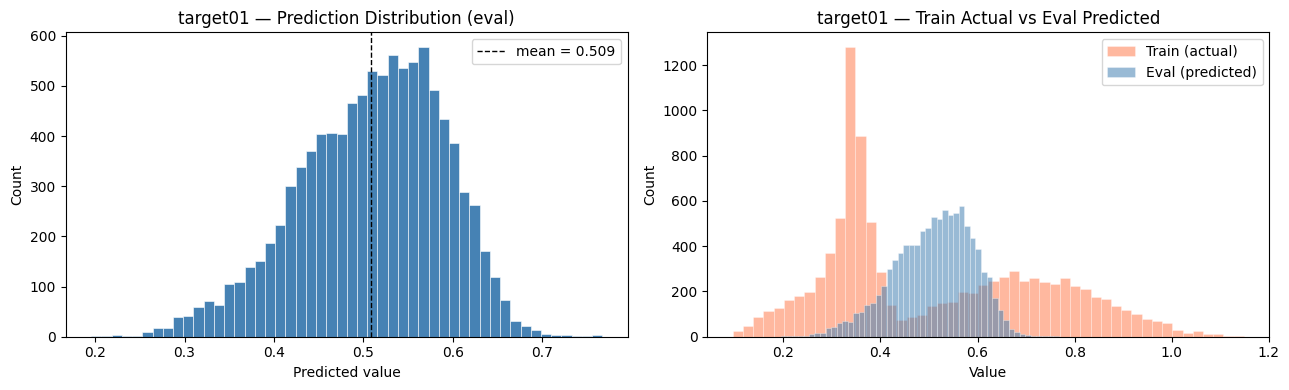

In [11]:
# Prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(eval_preds, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(eval_preds.mean(), color="black", linestyle="--", linewidth=1,
                label=f"mean = {eval_preds.mean():.3f}")
axes[0].set_title("target01 — Prediction Distribution (eval)", fontsize=12)
axes[0].set_xlabel("Predicted value")
axes[0].set_ylabel("Count")
axes[0].legend()

# Train target vs predicted comparison
axes[1].hist(y_train, bins=50, alpha=0.55, color="coral", edgecolor="white", linewidth=0.4, label="Train (actual)")
axes[1].hist(eval_preds, bins=50, alpha=0.55, color="steelblue", edgecolor="white", linewidth=0.4, label="Eval (predicted)")
axes[1].set_title("target01 — Train Actual vs Eval Predicted", fontsize=12)
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

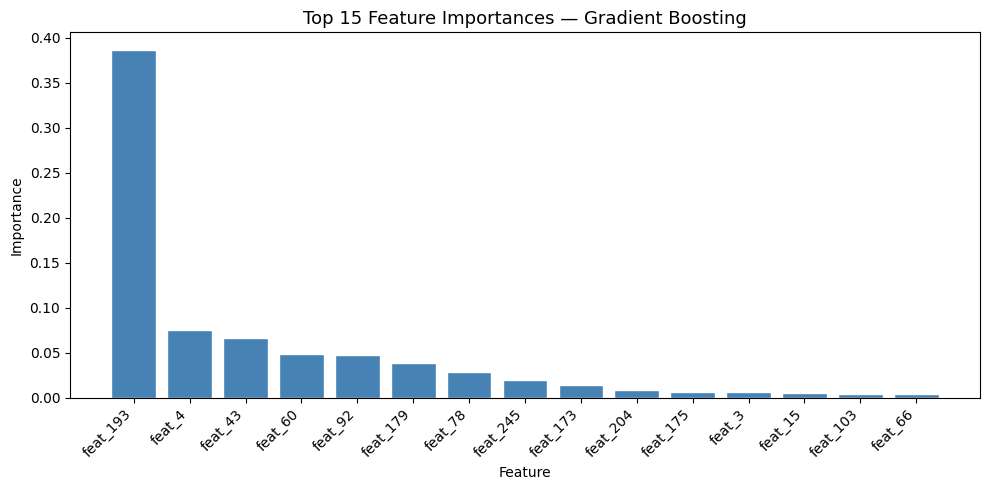

In [12]:
# Top 15 most important features
importances = model.feature_importances_
feature_names = train_features.columns.tolist()

top_n = 15
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 5))
plt.bar(
    [feature_names[i] for i in top_idx],
    importances[top_idx],
    color="steelblue", edgecolor="white"
)
plt.title(f"Top {top_n} Feature Importances — Gradient Boosting", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 8. Summary

The pipeline executed the following steps:

| Step | Action | Output |
|---|---|---|
| 1 | Load data | `train_features`, `train_targets`, `eval_features` |
| 2 | Explore data | Shapes, statistics, distributions |
| 3 | Train model | `GradientBoostingRegressor` on `target01` |
| 4 | Predict | 10,000 predictions on evaluation set |
| 5 | Save | `predictions/target01_predictions.csv` |
| 6 | Visualise | Prediction distribution, feature importances |

**Key results:**

| Metric | Value |
|---|---|
| RMSE (eval) | 0.0740 |
| MAE (eval) | 0.0652 |
| R² (eval) | 0.688 |

Gradient Boosting outperformed all baseline models, explaining ~69% of the variance in `target01`.

For the rule-based `target02` model, see `src/predict_target02.py`.